Sample 1: 0.5452
Sample 2: 0.5443
Sample 3: 0.5494
Epoch 1, Loss: 0.2386
Epoch 2, Loss: 0.2385
Epoch 3, Loss: 0.2384
Epoch 4, Loss: 0.2382
Epoch 5, Loss: 0.2381
Epoch 6, Loss: 0.2380
Epoch 7, Loss: 0.2379
Epoch 8, Loss: 0.2377
Epoch 9, Loss: 0.2376
Epoch 10, Loss: 0.2375


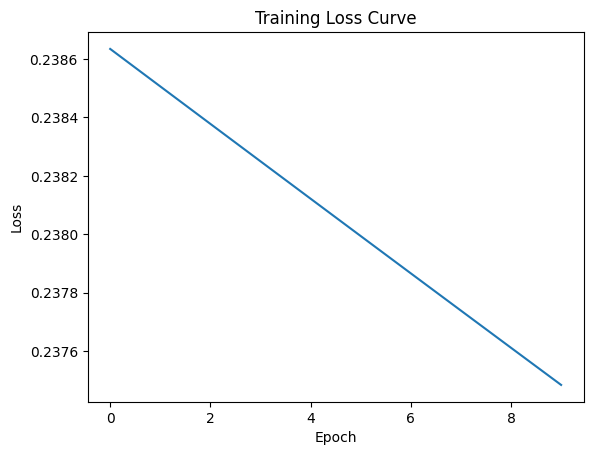

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Sigmoid functions
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(a):
    return a * (1 - a)

# Weights
w1, w2, w3, w4 = 0.67, 0.60, 0.89, 0.60
w5, w6, w7, w8 = -0.77, -0.88, -0.21, -0.63
w9, w10 = 0.72, -0.10

# Biases 
b1 = -0.43
b2 = -0.35

# Dataset
X = np.array([
    [0.2, 0.8],
    [0.9, 0.4],
    [0.1, 0.2]
])

y = np.array([1, 1, 0])

# Forward pass
def forward(x):
    x1, x2 = x[0], x[1]
    
    # Hidden Layer 1
    z1_1 = w1*x1 + w3*x2 + b1
    a1_1 = sigmoid(z1_1)
    
    z2_1 = w2*x1 + w4*x2 + b1
    a2_1 = sigmoid(z2_1)
    
    # Hidden Layer 2
    z1_2 = w5*a1_1 + w7*a2_1 + b2
    a1_2 = sigmoid(z1_2)
    
    z2_2 = w6*a1_1 + w8*a2_1 + b2
    a2_2 = sigmoid(z2_2)
    
    # Output
    z3 = w9*a1_2 + w10*a2_2
    y_hat = sigmoid(z3)
    
    return y_hat, (a1_1, a2_1, a1_2, a2_2)

# Test forward pass
for i in range(3):
    y_hat, _ = forward(X[i])
    print(f"Sample {i+1}: {y_hat:.4f}")

    ###########################################################
    # Loss function (MSE)
def compute_loss():
    total_loss = 0
    for i in range(3):
        y_hat, _ = forward(X[i])
        total_loss += (y[i] - y_hat) ** 2
    return total_loss / 3


# Backpropagation (for ONE sample)
def backward(x, y_true):
    global w1,w2,w3,w4,w5,w6,w7,w8,w9,w10,b1,b2
    
    x1, x2 = x[0], x[1]
    
    # Forward (reuse values)
    y_hat, (a1_1, a2_1, a1_2, a2_2) = forward(x)
    
    # ---- OUTPUT LAYER ----
    delta3 = -2*(y_true - y_hat) * sigmoid_derivative(y_hat)
    
    dw9 = delta3 * a1_2
    dw10 = delta3 * a2_2
    
    # ---- HIDDEN LAYER 2 ----
    delta2_1 = (w9 * delta3) * sigmoid_derivative(a1_2)
    delta2_2 = (w10 * delta3) * sigmoid_derivative(a2_2)
    
    dw5 = delta2_1 * a1_1
    dw6 = delta2_2 * a1_1
    dw7 = delta2_1 * a2_1
    dw8 = delta2_2 * a2_1
    
    db2 = delta2_1 + delta2_2
    
    # ---- HIDDEN LAYER 1 ----
    delta1_1 = (w5*delta2_1 + w7*delta2_2) * sigmoid_derivative(a1_1)
    delta1_2 = (w6*delta2_1 + w8*delta2_2) * sigmoid_derivative(a2_1)
    
    dw1 = delta1_1 * x1
    dw2 = delta1_2 * x1
    dw3 = delta1_1 * x2
    dw4 = delta1_2 * x2
    
    db1 = delta1_1 + delta1_2
    
    return dw1,dw2,dw3,dw4,dw5,dw6,dw7,dw8,dw9,dw10,db1,db2


# Training loop
def train(epochs=10, lr=0.1):
    global w1,w2,w3,w4,w5,w6,w7,w8,w9,w10,b1,b2
    
    losses = []
    
    for epoch in range(epochs):
        
        # Loop through samples
        for i in range(3):
            grads = backward(X[i], y[i])
            
            # Unpack gradients
            dw1,dw2,dw3,dw4,dw5,dw6,dw7,dw8,dw9,dw10,db1,db2 = grads
            
            # Update weights
            w1 -= lr * dw1
            w2 -= lr * dw2
            w3 -= lr * dw3
            w4 -= lr * dw4
            
            w5 -= lr * dw5
            w6 -= lr * dw6
            w7 -= lr * dw7
            w8 -= lr * dw8
            
            w9 -= lr * dw9
            w10 -= lr * dw10
            
            b1 -= lr * db1
            b2 -= lr * db2
        
        # Track loss
        loss = compute_loss()
        losses.append(loss)
        
        print(f"Epoch {epoch+1}, Loss: {loss:.4f}")
    
    return losses
losses = train(epochs=10, lr=0.1)
# import matplotlib.pyplot as plt

plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.show()